# Model C Rule-Based Sector Impact Engine — Explore Pipeline

สมุดนี้ให้รันทีละ cell เพื่อทำความเข้าใจ pipeline ทั้ง 3 ชั้นของ `exp_03`:

```
[FOMC/Beige Book text] → R1 market data → R2 shock classification
        → R3 LLM extraction (Qwen) → R4 rule engine → R5 validation กับ CAR จริง
```

**ข้อมูลทั้งหมดโหลดจากไฟล์ที่รันไว้แล้วใน `model_c_rulebase/data/`** — ไม่มีการเรียก Qwen API
หรือดึงข้อมูลใหม่ในสมุดนี้เลย (ปลอดภัยรันซ้ำได้เรื่อยๆ ไม่เสีย quota) รายละเอียดตัวเลขจริงและ
บั๊กที่เจอระหว่างทางอยู่ใน `experiments/log.md` (exp_03 Phase R1-R6)

## Setup — หา project root และ import โมดูลที่ใช้จริง (ไม่ mock)

In [1]:
import sys
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

def find_project_root(marker="CLAUDE.md"):
    p = Path.cwd().resolve()
    for parent in [p] + list(p.parents):
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f"ไม่พบ {marker} ในโฟลเดอร์แม่ใดๆ ของ {p}")

PROJECT_ROOT = find_project_root()
sys.path.insert(0, str(PROJECT_ROOT))
DATA_DIR = PROJECT_ROOT / "model_c_rulebase" / "data"

from model_c_rulebase.engine import sector_rules
from model_c_rulebase.engine.sector_rules import SECTORS, CHANNELS, MarketContext, StructuredVars, score_event

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /Users/boeing/Desktop/SNP-claude


## ส่วน 1 — Market data (R1)

โหลด `fomc_market_context.csv` — market context ที่จับคู่กับข่าว FOMC/Beige Book แต่ละชิ้น
คำนวณจาก FRED (DGS2, DGS10, DTWEXBGS, VIXCLS) + SPY (yfinance) ในวันประกาศ (`t0`) เทียบวันก่อน
หน้า (`t_prev`)

In [2]:
ctx = pd.read_csv(DATA_DIR / "fomc_market_context.csv")
ctx["date"] = pd.to_datetime(ctx["date"])
print(f"{len(ctx)} ข่าว, {ctx['date'].min().date()} -> {ctx['date'].max().date()}")
ctx.head(5)

452 ข่าว, 1999-03-17 -> 2026-07-15


,date,source,url,t_prev,t0,rate_surprise,equity_move,curve_slope_delta,vix_delta,dxy_delta,shock_type
0,1999-03-17,Beige_Book,https://www.federalreserve.gov/fomc/beigebook/...,1999-03-16,1999-03-17,0.04,-0.004304,-0.01,0.42,NaN,policy_tightening
1,1999-05-05,Beige_Book,https://www.federalreserve.gov/fomc/beigebook/...,1999-05-04,1999-05-05,-0.03,0.007944,0.01,-0.43,NaN,policy_easing
2,1999-05-18,FOMC_statement,https://www.federalreserve.gov/boarddocs/press...,1999-05-17,1999-05-18,0.07,-0.001863,-0.05,-0.02,NaN,policy_tightening
3,1999-06-16,Beige_Book,https://www.federalreserve.gov/fomc/beigebook/...,1999-06-15,1999-06-16,-0.05,0.019112,0.01,-3.51,NaN,policy_easing
4,1999-06-30,FOMC_statement,https://www.federalreserve.gov/boarddocs/press...,1999-06-29,1999-06-30,-0.15,0.018114,0.03,-1.42,NaN,policy_easing


**คำอธิบายแต่ละคอลัมน์:**

| คอลัมน์ | ความหมาย |
|---|---|
| `t_prev`, `t0` | trading date คู่ที่ใช้คำนวณ — `t0` = trading day แรกที่ >= วันประกาศข่าว, `t_prev` = trading day ก่อนหน้า `t0` |
| `rate_surprise` | ΔDGS2 (2-year Treasury yield) ระหว่าง `t_prev` → `t0` — "target factor" ตาม Gürkaynak-Sack-Swanson (2005) |
| `equity_move` | SPY return วันประกาศ (`t0`) |
| `curve_slope_delta` | Δ(DGS10 − DGS2) — ความชัน yield curve เปลี่ยนแค่ไหน (ป้อน channel C3 ใน R4) |
| `vix_delta` | ΔVIX (VIXCLS) — ตัวปรับ amplitude ใน R4 (VIX amplifier) |
| `dxy_delta` | Δ dollar index (DTWEXBGS) — `NaN` สำหรับข่าวก่อน 2006-01-02 (แหล่งข้อมูลยังไม่มีย้อนหลังไกลขนาดนั้น ไม่ใช่บั๊ก) |
| `shock_type` | ผลจาก Phase R2 (ดูส่วนถัดไป) |

## ส่วน 2 — Shock classification (R2)

Jarociński & Karadi (2020) sign restriction: แบ่งข่าวเป็น 4 ประเภทจากเครื่องหมายร่วมของ
`rate_surprise` x `equity_move` — แต่ในข้อมูลจริงมีข่าว 12.8% ที่ `rate_surprise` เท่ากับ 0 เป๊ะ
(DGS2 ไม่ขยับเลย กระจุกตัวช่วง ZIRP 2009-2018) ซึ่งจัด quadrant ไม่ได้ — เก็บเป็นประเภทที่ 5
(`no_rate_surprise`) แยกไว้ต่างหาก **ไม่ซ่อนไว้** แม้จะไม่ได้อยู่ในกราฟหลักที่ขอ

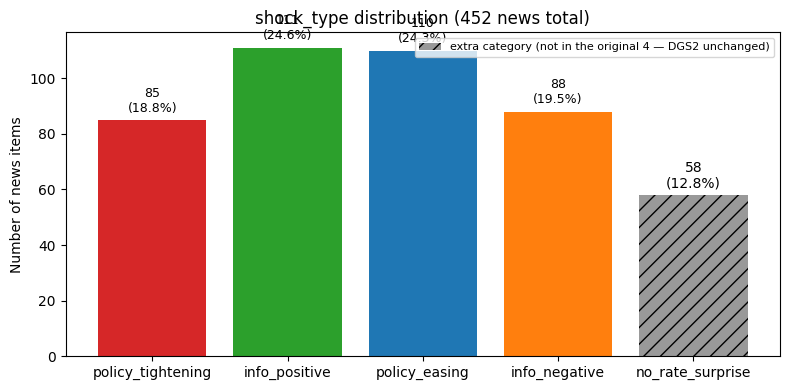

In [3]:
order_4 = ["policy_tightening", "info_positive", "policy_easing", "info_negative"]
counts = ctx["shock_type"].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#d62728", "#2ca02c", "#1f77b4", "#ff7f0e"]
bars_4 = ax.bar(order_4, [counts[s] for s in order_4], color=colors)
extra = counts.get("no_rate_surprise", 0)
ax.bar(["no_rate_surprise"], [extra], color="#999999", hatch="//",
       label="extra category (not in the original 4 — DGS2 unchanged)")

for b in list(bars_4):
    h = b.get_height()
    ax.text(b.get_x() + b.get_width() / 2, h + 3, f"{h}\n({h/len(ctx)*100:.1f}%)",
            ha="center", fontsize=9)
ax.bar_label(ax.containers[-1], labels=[f"{extra}\n({extra/len(ctx)*100:.1f}%)"], padding=3)

ax.set_ylabel("Number of news items")
ax.set_title(f"shock_type distribution ({len(ctx)} news total)")
ax.legend(loc="upper right", fontsize=8)
plt.tight_layout()
plt.show()

ตัวอย่างข่าวจริง 1 ข่าวต่อประเภท (เลือกจาก FOMC statement ที่มี structured vars ครบจาก R3 ด้วย
เพื่อใช้ต่อในส่วน 3-4) — โหลดข้อความข่าวดิบมาโชว์ headline/ย่อหน้าแรกประกอบเหตุผลการจัดประเภท

In [4]:
news_raw = pd.read_parquet(PROJECT_ROOT / "data" / "raw" / "macro_news_raw.parquet")
news_raw["date"] = pd.to_datetime(news_raw["date"])

examples = {
    "policy_tightening": "2026-06-17",
    "info_positive": "2025-10-29",
    "policy_easing": "2025-12-10",
    "info_negative": "2024-05-01",
}

for shock_type, date_str in examples.items():
    row = ctx[(ctx["date"] == date_str) & (ctx["source"] == "FOMC_statement")].iloc[0]
    text_row = news_raw[(news_raw["date"] == date_str) & (news_raw["source"] == "FOMC_statement")].iloc[0]
    print("=" * 78)
    print(f"{shock_type}  |  {date_str}")
    print(f"  rate_surprise = {row['rate_surprise']:+.3f}   equity_move = {row['equity_move']:+.3%}")
    sign_rate = "ขึ้น (+)" if row["rate_surprise"] > 0 else "ลง (−)"
    sign_eq = "บวก (+)" if row["equity_move"] > 0 else "ลบ (−)"
    print(f"  เหตุผล: yield {sign_rate}, equity {sign_eq} วันประกาศ -> quadrant นี้")
    print(f"  ข้อความ (300 ตัวอักษรแรก): {text_row['text'][:300].strip()}...")
    print()


policy_tightening  |  2026-06-17
  rate_surprise = +0.150   equity_move = -1.249%
  เหตุผล: yield ขึ้น (+), equity ลบ (−) วันประกาศ -> quadrant นี้
  ข้อความ (300 ตัวอักษรแรก): June 17, 2026
Federal Reserve issues FOMC statement
For release at 2:00 p.m. EDT
Share
The Federal Open Market Committee approved the following statement for release by a 12 â 0 vote:
The Committee decided to maintain the target range for the federal funds rate at 3-1/2 to 3-3/4 percent, in suppor...

info_positive  |  2025-10-29
  rate_surprise = +0.120   equity_move = +0.048%
  เหตุผล: yield ขึ้น (+), equity บวก (+) วันประกาศ -> quadrant นี้
  ข้อความ (300 ตัวอักษรแรก): October 29, 2025
Federal Reserve issues FOMC statement
For release at 2:00 p.m. EDT
Share
Available indicators suggest that economic activity has been expanding at a moderate pace. Job gains have slowed this year, and the unemployment rate has edged up but remained low through August; more recent in...

policy_easing  |  2025-12-10
  rate_su

## ส่วน 3 — LLM extraction (R3) — ดูข่าวเดียวละเอียด

เลือกข่าว **15 มี.ค. 2020** (FOMC ประกาศฉุกเฉินวันอาทิตย์ ลดดอกเบี้ยเหลือ 0% + QE ขนาดใหญ่ —
ข่าวเดียวกับที่ใช้ spot-check ใน R2) เพราะมี field ที่ไม่เป็น 0 ถึง 7/8 มิติ (เคสที่ข้อมูลอุดม
ที่สุดในชุดข้อมูล) และ `low_confidence=True` (self-consistency 2 รอบเห็นต่างกันบางมิติ — เห็นผล
ของ flag นี้ชัดเจนต่อใน R4)

ข้อความต้นฉบับเต็ม (ตัดตามที่ R3 ใช้จริง — `MAX_CURRENT_CHARS=6000` ตัวอักษร):

In [5]:
EXPLORE_DATE = "2020-03-15"
EXPLORE_SOURCE = "FOMC_statement"

full_text = news_raw[(news_raw["date"] == EXPLORE_DATE) & (news_raw["source"] == EXPLORE_SOURCE)].iloc[0]["text"]
print(full_text[:6000])

March 15, 2020
Federal Reserve issues FOMC statement
For release at 5:00 p.m. EDT
Share
The coronavirus outbreak has harmed communities and disrupted economic activity in many countries, including the United States. Global financial conditions have also been significantly affected. Available economic data show that the U.S. economy came into this challenging period on a strong footing. Information received since the Federal Open Market Committee met in January indicates that the labor market remained strong through February and economic activity rose at a moderate rate. Job gains have been solid, on average, in recent months, and the unemployment rate has remained low. Although household spending rose at a moderate pace, business fixed investment and exports remained weak. More recently, the energy sector has come under stress. On a 12âmonth basis, overall inflation and inflation for items other than food and energy are running below 2 percent. Market-based measures of inflation comp

↓ ตัวแปรทั้ง 8 มิติที่ Qwen สกัดออกมา พร้อม evidence quote ที่ใช้ตัดสินแต่ละมิติ (field ที่ค่า = 0 ไม่บังคับมี quote)

In [6]:
vars_df = pd.read_csv(DATA_DIR / "fomc_structured_vars.csv")
FIELDS = ["stance_delta", "growth_delta", "inflation_delta", "labor_delta",
          "forward_guidance_delta", "balance_sheet_signal",
          "uncertainty_language", "financial_stability_concern"]

vrow = vars_df[(vars_df["date"] == EXPLORE_DATE) & (vars_df["source"] == EXPLORE_SOURCE)].iloc[0]
quotes = json.loads(vrow["evidence_quotes"])

table = pd.DataFrame({
    "field": FIELDS,
    "value": [vrow[f] for f in FIELDS],
    "evidence_quote": [quotes.get(f, "(= 0, ไม่บังคับมี quote)") for f in FIELDS],
})
print(f"low_confidence = {vrow['low_confidence']}  (self-consistency 2 รอบเห็นต่างกัน >1 ระดับในบาง field)")
pd.set_option("display.max_colwidth", 100)
table

low_confidence = True  (self-consistency 2 รอบเห็นต่างกัน >1 ระดับในบาง field)


,field,value,evidence_quote
0,stance_delta,-1,lower the target range for the federal funds rate to 0 to 1/4 percent
1,growth_delta,-1,The effects of the coronavirus will weigh on economic activity in the near term and pose risks t...
2,inflation_delta,-1,"On a 12‑month basis, overall inflation and inflation for items other than food and energy are ru..."
3,labor_delta,-1,"The labor market remained strong through February... More recently, the energy sector has come u..."
4,forward_guidance_delta,0,"(= 0, ไม่บังคับมี quote)"
5,balance_sheet_signal,2,over coming months the Committee will increase its holdings of Treasury securities by at least $...
6,uncertainty_language,1,The Committee will continue to monitor the implications of incoming information for the economic...
7,financial_stability_concern,2,The Federal Reserve is prepared to use its full range of tools to support the flow of credit to ...


## ส่วน 4 — Rule engine (R4) — เดินเครื่องข่าวเดียวกันจากส่วน 3

รันผ่าน `sector_rules.score_event()` จริง (โค้ดเดียวกับที่ใช้ใน R5 ไม่ได้ย่อ/mock) — สร้าง
`MarketContext` จาก R1/R2 (ส่วน 1) + `StructuredVars` จาก R3 (ส่วน 3) ของข่าว 15 มี.ค. 2020 แล้ว
ดูคะแนนของทั้ง 11 sector แยกตาม channel (C1-C7)

In [7]:
vix_p90 = ctx["vix_delta"].quantile(0.90)

mrow = ctx[(ctx["date"] == EXPLORE_DATE) & (ctx["source"] == EXPLORE_SOURCE)].iloc[0]
dxy = None if pd.isna(mrow["dxy_delta"]) else float(mrow["dxy_delta"])

def build_market(mrow, dxy):
    return MarketContext(
        rate_surprise=float(mrow["rate_surprise"]), equity_move=float(mrow["equity_move"]),
        curve_slope_delta=float(mrow["curve_slope_delta"]), vix_delta=float(mrow["vix_delta"]),
        dxy_delta=dxy, shock_type=mrow["shock_type"],
    )

def build_llm(vrow):
    return StructuredVars(**{f: int(vrow[f]) for f in FIELDS}, low_confidence=bool(vrow["low_confidence"]))

def breakdown_table(result):
    rows = []
    for sector in SECTORS:
        s = result["sectors"][sector]
        row = {"sector": sector, **s["contributions"], "score": s["score"]}
        rows.append(row)
    return pd.DataFrame(rows).set_index("sector").round(4)

market = build_market(mrow, dxy)
llm = build_llm(vrow)
result = score_event(market, llm, vix_p90)

print(f"shock_type = {result['shock_type']}")
print(f"VIX amplifier active: {result['vix_amplifier_active']}  (vix_delta={market.vix_delta:+.2f} vs p90={vix_p90:.2f})")
print(f"low_confidence dampener active: {result['low_confidence_dampener_active']}")
print(f"global_multiplier = {result['global_multiplier']:.3f}\n")

bt = breakdown_table(result)
bt

shock_type = info_negative
VIX amplifier active: True  (vix_delta=+24.86 vs p90=1.13)
low_confidence dampener active: True
global_multiplier = 0.700



,C1,C2,C3,C4,C5,C6,C7,score
sector,,,,,,,,
XLK,0.0910,-0.525,-0.0000,0.00,-0.1737,0.28,-0.0658,-0.3935
XLC,0.0546,-0.420,-0.0000,0.00,-0.0695,0.14,-0.1645,-0.4594
XLY,0.0455,-0.945,-0.0000,-0.49,-0.0695,0.28,-0.1316,-1.3106
XLP,0.0364,-0.105,-0.0000,-0.07,-0.0695,0.14,-0.0658,-0.1339
XLV,0.0364,-0.105,-0.0000,0.00,-0.0695,0.07,-0.0658,-0.1339
XLF,0.0182,-0.525,-0.0112,-1.05,0.0000,-0.00,0.0000,-1.5680
XLI,0.0273,-0.945,-0.0000,-0.28,-0.1390,-0.00,-0.1316,-1.4683
XLB,0.0273,-0.840,-0.0000,-0.21,-0.2432,-0.42,-0.1316,-1.8175
XLE,0.0182,-0.525,-0.0000,-0.14,-0.2085,-0.63,-0.0987,-1.5840


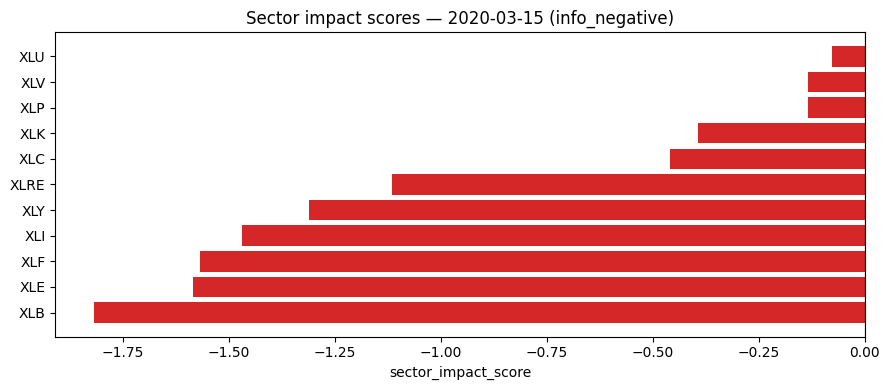

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
scores = bt["score"].sort_values()
colors = ["#d62728" if v < 0 else "#2ca02c" for v in scores]
ax.barh(scores.index, scores.values, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("sector_impact_score")
ax.set_title(f"Sector impact scores — {EXPLORE_DATE} ({result['shock_type']})")
plt.tight_layout()
plt.show()

## ส่วน 5 — Validation results (R5)

Heatmap ของ Spearman rho (rule engine score เทียบกับ CAR จริง) แยกตามหน้าต่างเวลา (N=1/3/21
วัน) x sector — จาก `r5_rho_table.csv` (คำนวณบน **train set เท่านั้น** ตาม pre-registered
protocol) เกณฑ์ผ่านที่ตั้งไว้ล่วงหน้าคือ `|rho| > 0.3` — cell ที่ผ่านจะถูกล้อมกรอบสีแดงไว้ชัดเจน

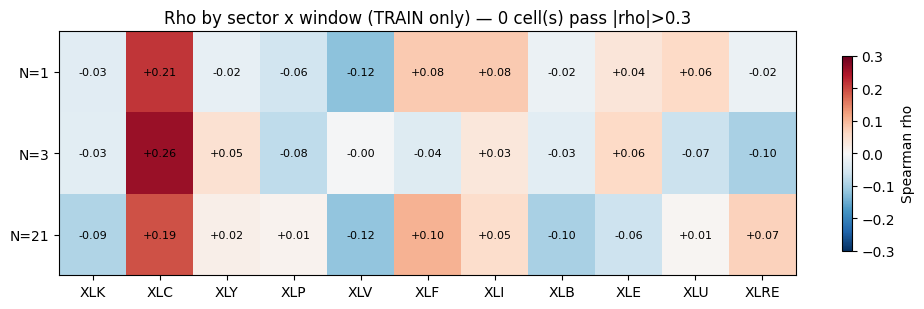

จำนวน cell ที่ผ่านเกณฑ์ |rho|>0.3 (กรอบแดงในภาพ): 0


In [9]:
rho_df = pd.read_csv(DATA_DIR / "r5_rho_table.csv")
by_sector = rho_df[rho_df["level"] == "by_sector"]
pivot = by_sector.pivot(index="window", columns="group", values="rho")
pivot = pivot[SECTORS]  # เรียง sector ให้อยู่ในลำดับเดียวกับที่ใช้ทั้งสมุด

fig, ax = plt.subplots(figsize=(10, 3.2))
vmax = 0.3  # ตรงกับเกณฑ์ pass/fail พอดี ให้สีสื่อระยะห่างจาก threshold ได้ตรงๆ
im = ax.imshow(pivot.values, cmap="RdBu_r", vmin=-vmax, vmax=vmax, aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f"N={n}" for n in pivot.index])

n_passing = 0
for i, n in enumerate(pivot.index):
    for j, sector in enumerate(pivot.columns):
        val = pivot.loc[n, sector]
        text = f"{val:+.2f}" if pd.notna(val) else "n/a"
        ax.text(j, i, text, ha="center", va="center", fontsize=8)
        if pd.notna(val) and abs(val) > 0.3:
            n_passing += 1
            ax.add_patch(mpatches.Rectangle((j - 0.5, i - 0.5), 1, 1, fill=False,
                                             edgecolor="red", linewidth=2.5))

plt.colorbar(im, ax=ax, label="Spearman rho", shrink=0.8)
ax.set_title(f"Rho by sector x window (TRAIN only) — {n_passing} cell(s) pass |rho|>0.3")
plt.tight_layout()
plt.show()

print(f"จำนวน cell ที่ผ่านเกณฑ์ |rho|>0.3 (กรอบแดงในภาพ): {n_passing}")

**สรุปผล (negative result, ตัวเลขจริงจาก R5):** ไม่มี cell ไหนในตาราง by-sector (และไม่มี cell
ไหนเลยจาก 216 cells ทั้งหมดรวม pooled/by-shock_type/sector×shock_type) ผ่านเกณฑ์
`|rho| > 0.3` พร้อม cluster-bootstrap CI ไม่คร่อม 0 ทั้งสองเงื่อนไขพร้อมกัน — heatmap ด้านบน
จึงไม่มีกรอบแดงเลย (ตรวจสอบโปรแกรมแล้วว่างจริง ไม่ใช่ threshold ตั้งสูงจนมองไม่เห็น) สอดคล้องกับ
`exp_01`/`exp_02` เดิมที่ก็ไม่พบสัญญาณเช่นกัน — rule engine เวอร์ชันทฤษฎีล้วนนี้ยังไม่พร้อมเป็น
component หลักของ Model C (ดูเหตุผลเต็มและข้อยกเว้นที่น่าสนใจ [XLV ทิศทางผิดคาด] ใน
`experiments/log.md` exp_03 Phase R5-R6)

## ส่วน 6 — ลองเล่นเอง (interactive)

**วิธีใช้:** เปลี่ยนค่า `EXPLORE_DATE`/`EXPLORE_SOURCE` ใน cell ถัดไป (เลือกจากคอลัมน์ `date`,
`source` ใน `ctx` ของส่วน 1) แล้วรันทุก cell ตั้งแต่ cell นี้ลงไปใหม่ — ใช้ helper function
(`build_market`, `build_llm`, `breakdown_table`) ที่นิยามไว้แล้วในส่วน 4

2008-12-16 (FOMC_statement) — shock_type = policy_easing
VIX amplifier: False, low_confidence dampener: False


,C1,C2,C3,C4,C5,C6,C7,score
sector,,,,,,,,
XLK,0.10,-1.0,-0.000,0.0,0.3115,0.4,-0.10,-0.2885
XLC,0.06,-0.8,-0.000,0.0,0.1246,0.2,-0.25,-0.6654
XLY,0.05,-1.8,-0.000,-0.0,0.1246,0.4,-0.20,-1.4254
XLP,0.04,-0.2,-0.000,-0.0,0.1246,0.2,-0.10,0.0646
XLV,0.04,-0.2,-0.000,0.0,0.1246,0.1,-0.10,-0.0354
XLF,0.02,-1.0,-0.012,-0.0,-0.0000,-0.0,0.00,-0.9920
XLI,0.03,-1.8,-0.000,-0.0,0.2492,-0.0,-0.20,-1.7208
XLB,0.03,-1.6,-0.000,-0.0,0.4361,-0.6,-0.20,-1.9339
XLE,0.02,-1.0,-0.000,-0.0,0.3738,-0.9,-0.15,-1.6562


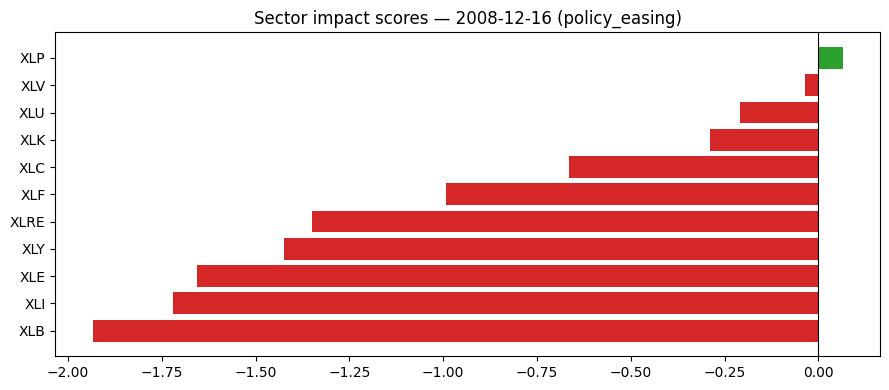

In [10]:
EXPLORE_DATE = "2008-12-16"    # <-- เปลี่ยนตรงนี้ เช่น "2015-12-16" (ขึ้นดอกเบี้ยครั้งแรกในรอบ ~10 ปี)
EXPLORE_SOURCE = "FOMC_statement"

mrow2 = ctx[(ctx["date"] == EXPLORE_DATE) & (ctx["source"] == EXPLORE_SOURCE)]
vrow2 = vars_df[(vars_df["date"] == EXPLORE_DATE) & (vars_df["source"] == EXPLORE_SOURCE)]

if mrow2.empty or vrow2.empty:
    print(f"ไม่พบข่าว {EXPLORE_DATE} ({EXPLORE_SOURCE}) ในข้อมูล หรือ R3 สกัดไม่สำเร็จสำหรับข่าวนี้")
else:
    mrow2, vrow2 = mrow2.iloc[0], vrow2.iloc[0]
    dxy2 = None if pd.isna(mrow2["dxy_delta"]) else float(mrow2["dxy_delta"])
    market2 = build_market(mrow2, dxy2)
    llm2 = build_llm(vrow2)
    result2 = score_event(market2, llm2, vix_p90)

    print(f"{EXPLORE_DATE} ({EXPLORE_SOURCE}) — shock_type = {result2['shock_type']}")
    print(f"VIX amplifier: {result2['vix_amplifier_active']}, low_confidence dampener: {result2['low_confidence_dampener_active']}")
    bt2 = breakdown_table(result2)
    display(bt2)

    fig, ax = plt.subplots(figsize=(9, 4))
    scores2 = bt2["score"].sort_values()
    ax.barh(scores2.index, scores2.values, color=["#d62728" if v < 0 else "#2ca02c" for v in scores2])
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Sector impact scores — {EXPLORE_DATE} ({result2['shock_type']})")
    plt.tight_layout()
    plt.show()

### ทดลองปรับสมมติฐาน — เปลี่ยนค่า loading matrix เอง

`LOADING_MATRIX` เป็นค่าจากทฤษฎี (ห้ามถือเป็นค่าจริง — ดู docstring ใน `sector_rules.py`) ลองแก้
ค่าบางช่องแล้วดูว่าคะแนนเปลี่ยนไปแค่ไหน เช่น สมมติว่า Utilities (`XLU`) ไวต่อ duration
(`C1`) **น้อยกว่า**ที่ทฤษฎีบอกไว้มาก (จาก −0.9 เป็น −0.3) — ใช้ข่าวเดียวกับ cell ก่อนหน้า

In [11]:
import copy

SECTOR_TO_EDIT, CHANNEL_TO_EDIT, NEW_VALUE = "XLU", "C1", -0.3

original_matrix = copy.deepcopy(sector_rules.LOADING_MATRIX)
old_value = sector_rules.LOADING_MATRIX[SECTOR_TO_EDIT][CHANNEL_TO_EDIT]

sector_rules.LOADING_MATRIX[SECTOR_TO_EDIT][CHANNEL_TO_EDIT] = NEW_VALUE
result_modified = score_event(market2, llm2, vix_p90)
sector_rules.LOADING_MATRIX = original_matrix  # คืนค่าเดิม กัน state ค้างไปกระทบ cell อื่น

before = breakdown_table(result2)["score"]
after = breakdown_table(result_modified)["score"]
compare = pd.DataFrame({"original": before, f"{SECTOR_TO_EDIT}.{CHANNEL_TO_EDIT}={NEW_VALUE}": after})
compare["diff"] = compare.iloc[:, 1] - compare.iloc[:, 0]
print(f"{SECTOR_TO_EDIT}.{CHANNEL_TO_EDIT}: {old_value} -> {NEW_VALUE}")
compare.round(4)

XLU.C1: -0.9 -> -0.3


,original,XLU.C1=-0.3,diff
sector,,,
XLK,-0.2885,-0.2885,0.00
XLC,-0.6654,-0.6654,0.00
XLY,-1.4254,-1.4254,0.00
XLP,0.0646,0.0646,0.00
XLV,-0.0354,-0.0354,0.00
XLF,-0.9920,-0.9920,0.00
XLI,-1.7208,-1.7208,0.00
XLB,-1.9339,-1.9339,0.00
XLE,-1.6562,-1.6562,0.00
